## Lista de Exercícios da Disciplina Aprendizagem de Máquina

Professor: Dr. Leandro Carlos de Souza 

Alunos:
* Thiago Ney Evaristo Rodrigues
* Villeneve de Oliveira Soares

### Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    adjusted_rand_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import tensorflow as tf
from tensorflow import keras

random_state = 42

2025-11-10 21:51:24.210267: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 21:51:24.226881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762822284.242615   65816 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762822284.247726   65816 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-10 21:51:24.263364: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Etapa 1 - Geração dos dados

Gere dois conjuntos de dados correspondentes a duas classes hipotéticas, seguindo distribuições normais bivariadas independentes:

* Classe 1:
$\mu _x = 25$, $\mu _y = 10$, $\sigma _x ^2 = 100$, $\sigma _y ^2 = 25$ e $N = 150 \ \text{Elementos}$

* Classe 2:
$\mu _x = 60$, $\mu _y = 30$, $\sigma _x ^2 = 36$, $\sigma _y ^2 = 144$ e $N = 150 \ \text{Elementos}$

Combine ambas as classes em um único conjunto de 300 pontos.

In [2]:
np.random.seed(random_state)

# Dados do Enunciado

n_samples = 150

mu_zero = [25, 10]
cov_zero = [[100, 0], [0, 25]]

mu_one = [60, 30]
cov_one = [[36, 0], [0, 144]] 

# Geração do Primeiro Conjunto de Dados

class_zero = np.random.multivariate_normal(mu_zero, cov_zero, n_samples)
df_zero = pd.DataFrame(class_zero, columns=["x", "y"])
df_zero["class"] = 0

# Geração do Segundo Conjunto de Dados

class_one = np.random.multivariate_normal(mu_one, cov_one, n_samples)
df_one = pd.DataFrame(class_one, columns=["x", "y"])
df_one["class"] = 1

df = pd.concat((df_zero, df_one))
display(df)

data = df[["x", "y"]].values
class_true = df["class"].values

,x,y,class
0,29.967142,9.308678,0
1,31.476885,17.615149,0
2,22.658466,8.829315,0
3,40.792128,13.837174,0
4,20.305256,12.712800,0
...,...,...,...
145,57.134055,30.858795,1
146,62.001973,35.747758,1
147,56.939902,42.450479,1
148,54.127418,26.761501,1


### Etapa 2 - Aplicação do K-means

1. Aplique o algoritmo K-means com $k=2$.
2. Visualize os clusters resultantes, plotando o agrupamento em cores diferentes.
3. Calcule a matriz de confusão.
4. Calcule o índice de Rand ajustado para esse agrupamento.

In [3]:
# Aplicação do Algoritmo k-means

kmeans = KMeans(n_clusters=2, random_state=random_state)
class_pred = kmeans.fit_predict(df.iloc[:, 0:2])

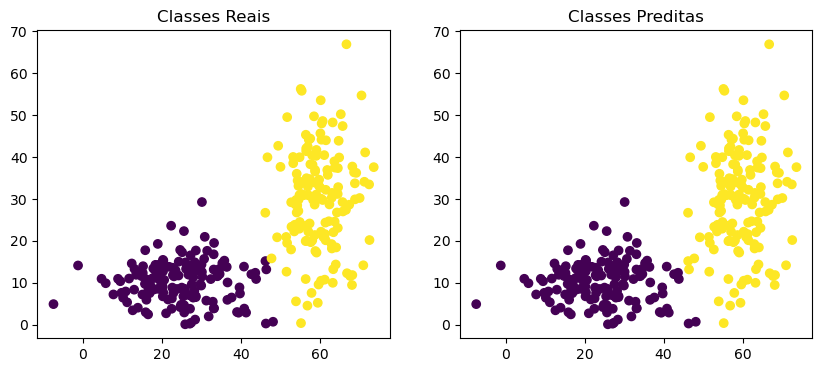

In [4]:
# Plot dos Clusters Resultantes

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(df.loc[:, "x"], df.loc[:, "y"], c=df.loc[:, "class"])
axs[0].set_title("Classes Reais")
axs[1].scatter(df.loc[:, "x"], df.loc[:, "y"], c=class_pred)
axs[1].set_title("Classes Preditas");

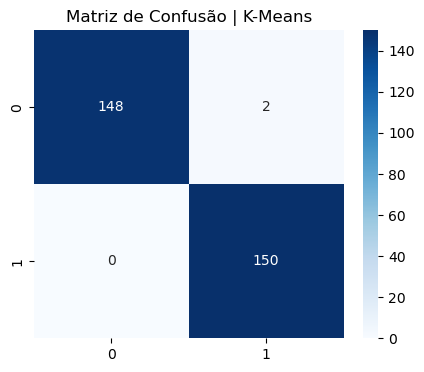

In [5]:
# Plot da Matriz de Confusão

cm = confusion_matrix(class_true, class_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Matriz de Confusão | K-Means");

In [6]:
# Métrica de Avaliação

ari = adjusted_rand_score(class_true, class_pred)
print(f"O Índice de Rand Ajustado (ARI) é: {ari:.4f}")

O Índice de Rand Ajustado (ARI) é: 0.9734


Este valor indica que os agrupamentos (clusters) definidos pelo algoritmo de agrupamento são quase idênticos aos agrupamentos verdadeiros.

### Etapa 3 - Aplicação do Fuzzy C-means

1. Aplique o algoritmo Fuzzy C-means (use $c=2$).
2. Analise os graus de pertinência (membership) de cada ponto a cada cluster.
3. Plote os pontos colorindo-os de acordo com o grau de pertinência à Classe 1 (por exemplo, intensidade da cor → grau de pertencimento).

In [7]:
# Aplicação do Algoritmo Fuzzy C-means

c = 2
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data.T, c, m=2.0, error=0.005, maxiter=1000, seed=random_state
)

# Explicação dos Hiperparâmetros:
# 
# data.T: Transposição do conjunto de dados a serem agrupados
# c: Números de clusters
# m: O expoente de "nebulosidade" (fuzziness). Controla o quão sobrepostos (fuzzy) os clusters podem ser. m=2.0 é o valor padrão recomendado na documentação.
# error: Erro de Convergência. O critério de parada principal. error=0.005 é o valor padrão recomendado na documentação.
# maxiter: Máximo de Iterações. O critério de parada secundário. maxiter=1000 é o valor padrão recomendado na documentação.

print(f"Centros Encontrados para os Clusters:\n{cntr}\n")
print(f"Coeficiente de Partição Difuso (Fuzzy Partition Coefficient, FPC): {fpc:.4f}")

Centros Encontrados para os Clusters:
[[59.47418797 30.76989607]
 [24.27498701 10.16440833]]

Coeficiente de Partição Difuso (Fuzzy Partition Coefficient, FPC): 0.8738


Este valor de FPC indica que os clusters que o algoritmo encontrou são bem definidos e relativamente "nítidos", com pouca sobreposição entre eles.

In [8]:
# Análise dos Graus de Pertinência para cada Cluster
# Será realizado a conversão de formato (Array Numpy) para um Dataframe, a fim de facilitar a manipulação

u_df = pd.DataFrame(u.T, columns=[f"Cluster_{i}" for i in range(c)])
df = df.reset_index(drop=True)
u_df = u_df.reset_index(drop=True)
df = pd.concat([df, u_df], axis=1)

display(df)

,x,y,class,Cluster_0,Cluster_1
0,29.967142,9.308678,0,0.024284,0.975716
1,31.476885,17.615149,0,0.100896,0.899104
2,22.658466,8.829315,0,0.002387,0.997613
3,40.792128,13.837174,0,0.310512,0.689488
4,20.305256,12.712800,0,0.011821,0.988179
...,...,...,...,...,...
295,57.134055,30.858795,1,0.996376,0.003624
296,62.001973,35.747758,1,0.985221,0.014779
297,56.939902,42.450479,1,0.936571,0.063429
298,54.127418,26.761501,1,0.963134,0.036866


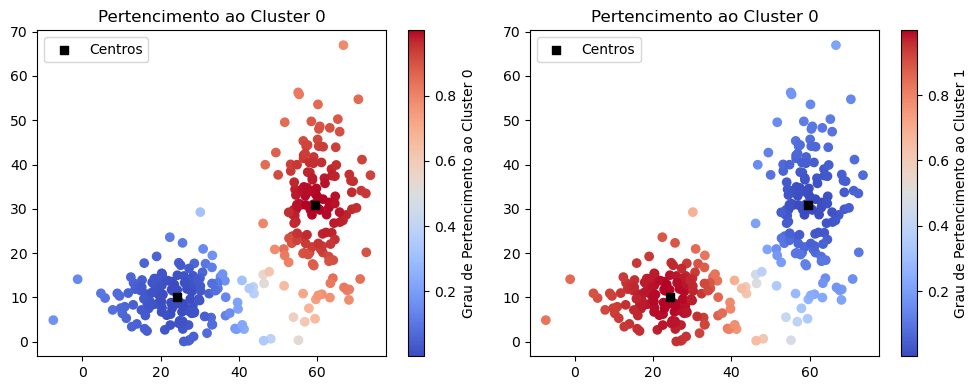

In [9]:
# Plot do Grau de Pertinência para cada Cluster

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

scatter0 = axs[0].scatter(df["x"], df["y"], c=df["Cluster_0"], cmap="coolwarm")
fig.colorbar(scatter0, ax=axs[0], label="Grau de Pertencimento ao Cluster 0")
axs[0].scatter(cntr[:, 0], cntr[:, 1], marker="s", c="black", label="Centros")
axs[0].set_title("Pertencimento ao Cluster 0")
axs[0].legend()

scatter1 = axs[1].scatter(df["x"], df["y"], c=df["Cluster_1"], cmap="coolwarm")
fig.colorbar(scatter1, ax=axs[1], label="Grau de Pertencimento ao Cluster 1")
axs[1].scatter(cntr[:, 0], cntr[:, 1], marker="s", c="black", label="Centros")
axs[1].set_title("Pertencimento ao Cluster 0")
axs[1].legend()

plt.tight_layout()

### Etapa 4 - Aplicação da Regressão Logística

1. Treine um modelo de Regressão Logística para classificar as duas classes verdadeiras.
2. Plote a fronteira de decisão obtida pelo modelo.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

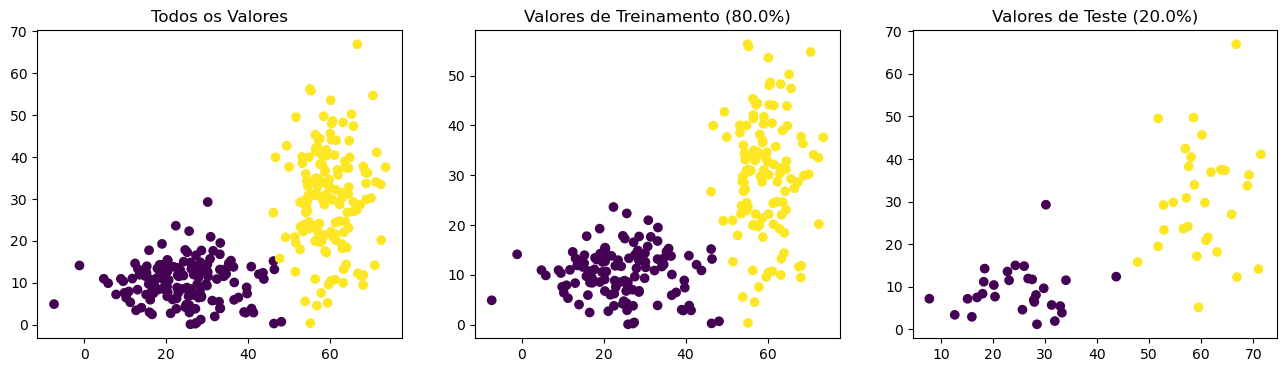

In [10]:
# Divisão dos Dados de Treino e Teste

test_size = 0.2 # 20% dos Valores para Teste
X_train, X_test, y_train, y_test = train_test_split(
    data, class_true, test_size=test_size, random_state=random_state
)

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].scatter(df.loc[:, "x"], df.loc[:, "y"], c=df.loc[:, "class"])
axs[0].set_title("Todos os Valores")
axs[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train)
axs[1].set_title(f"Valores de Treinamento ({(1-test_size)*100}%)")
axs[2].scatter(X_test[:, 0], X_test[:, 1], c=y_test)
axs[2].set_title(f"Valores de Teste ({test_size*100}%)");

In [11]:
# Aplicação do Modelo de Regressão Logística

logistic_model = LogisticRegression(random_state=random_state)
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

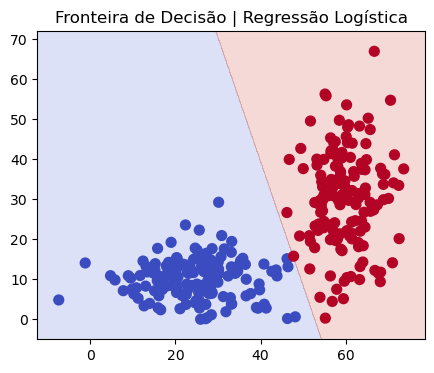

In [12]:
# Plot da Fronteira de Decisão

x_min, x_max = data[:, 0].min() - 5, data[:, 0].max() + 5
y_min, y_max = data[:, 1].min() - 5, data[:, 1].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

Z_lr = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z_lr, alpha=0.2, cmap="coolwarm")
plt.scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
plt.title("Fronteira de Decisão | Regressão Logística");

Desempenho do Modelo de Regressão Logística

Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-score: 1.0000


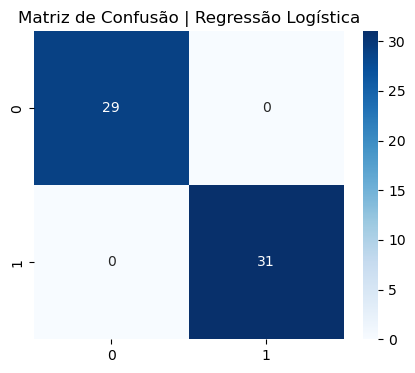

In [13]:
# Métricas de Avaliação

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Desempenho do Modelo de Regressão Logística")
print(f"\nAcurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Plot da Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Matriz de Confusão | Regressão Logística");

### Etapa 5 - Rede Neural Artificial

1. Crie e treine uma rede neural totalmente conectada (feedforward)
2. Plote a fronteira de decisão da RNA e compare com a da Regressão Logística.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

In [14]:
gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    print("Nenhuma GPU encontrada. O teste da GPU será pulado.")
else:
    print(f"Encontrada(s) {len(gpus)} GPU(s).")

Encontrada(s) 1 GPU(s).


In [15]:
num_classes = 2

input_ = keras.layers.Input(shape=X_train.shape[1:])

hidden1 = keras.layers.Dense(64, activation="relu")(input_)
hidden2 = keras.layers.Dense(128, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(64, activation="relu")(hidden2)

output = keras.layers.Dense(1, activation="sigmoid")(hidden3)

mlp_model = keras.Model(inputs=[input_], outputs=[output])

custom_optimizer = keras.optimizers.Adam(learning_rate=0.001)
mlp_model.compile(
    loss="binary_crossentropy", optimizer=custom_optimizer, metrics=["accuracy"]
)
mlp_model.summary()

# A função de ativação das camadas ocultas escolhida foi a relu, por ser a padrão na literatura para primeira arquitetura, geralmente alcançando bons resultados.
# A combinação da camada de ativação da função de ativação sigmoid para a camada de saída e a função de perda binary_crossentropy se deu pela classe de problema, classificação binária.

I0000 00:00:1762822292.974055   65816 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,833 (65.75 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = mlp_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
)

Epoch 1/150


I0000 00:00:1762822294.165308   66122 service.cc:148] XLA service 0x705eac00c330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762822294.165355   66122 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-11-10 21:51:34.180447: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1762822294.267889   66122 cuda_dnn.cc:529] Loaded cuDNN version 90101


1/8 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4062 - loss: 1.1334

I0000 00:00:1762822295.203782   66122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.5167 - loss: 0.7428 - val_accuracy: 0.5167 - val_loss: 0.5793
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5375 - loss: 0.6222 - val_accuracy: 0.5167 - val_loss: 0.5849
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5958 - loss: 0.5879 - val_accuracy: 0.6000 - val_loss: 0.5413
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5750 - loss: 0.5668 - val_accuracy: 0.6833 - val_loss: 0.5677
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6167 - loss: 0.5510 - val_accuracy: 0.7000 - val_loss: 0.5215
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6250 - loss: 0.5429 - val_accuracy: 0.6000 - val_loss: 0.5143
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6417 - loss: 0.5466 - val_accuracy: 0.6000 - val_loss: 0.5086
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6833 - loss: 0.5228 - val_accuracy: 0.6167 - val_loss: 0.4910
Epoch 9/15

Acurácia no Teste: 100.00%


<Figure size 640x480 with 0 Axes>

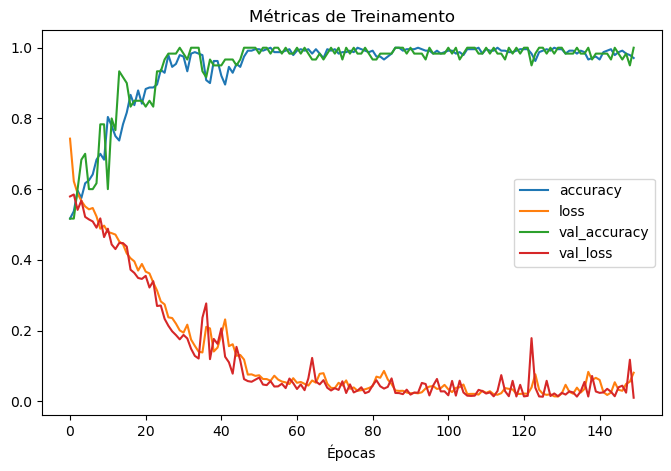

In [17]:
loss, accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"Acurácia no Teste: {accuracy * 100:.2f}%")

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas");

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 27s 846us/step


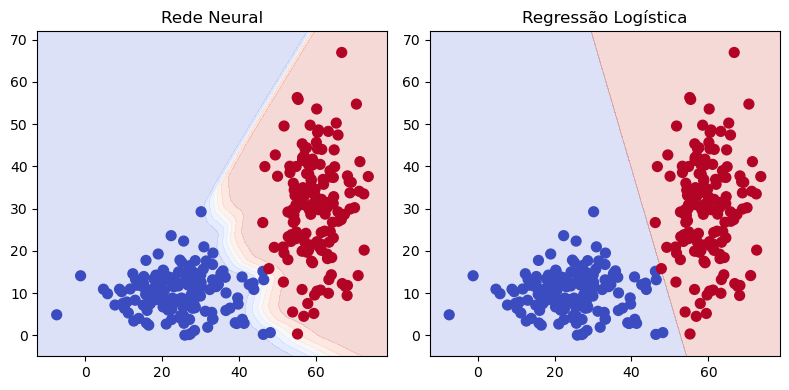

In [18]:
# Plot da Fronteira de Decisão

# x_min, x_max = data[:, 0].min() - 5, data[:, 0].max() + 5
# y_min, y_max = data[:, 1].min() - 5, data[:, 1].max() + 5

# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

Z_nn = mlp_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_nn = Z_nn.reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].contourf(xx, yy, Z_nn, alpha=0.2, cmap="coolwarm")
axs[0].scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
axs[0].set_title("Rede Neural")

axs[1].contourf(xx, yy, Z_lr, alpha=0.2, cmap="coolwarm")
axs[1].scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
axs[1].set_title("Regressão Logística");

plt.tight_layout()


Desempenho do Modelo de Redes Neurais

Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-score: 1.0000


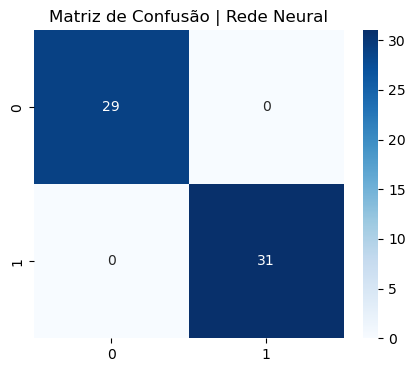

In [19]:
# Métricas de Avaliação

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Desempenho do Modelo de Redes Neurais")
print(f"\nAcurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Plot da Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Matriz de Confusão | Rede Neural");

### Etapa 6 - Máquina de Vetores de Suporte (SVM)

1. Treine um modelo de SVM.
2. Plote a fronteira de decisão obtida pelo SVM.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

In [20]:
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

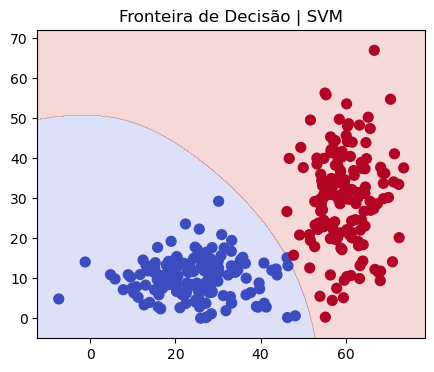

In [21]:
# Plot da Fronteira de Decisão

# x_min, x_max = data[:, 0].min() - 5, data[:, 0].max() + 5
# y_min, y_max = data[:, 1].min() - 5, data[:, 1].max() + 5

# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

Z_svm = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z_svm, alpha=0.2, cmap="coolwarm")
plt.scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
plt.title("Fronteira de Decisão | SVM");

Desempenho do Modelo de SVM

Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-score: 1.0000


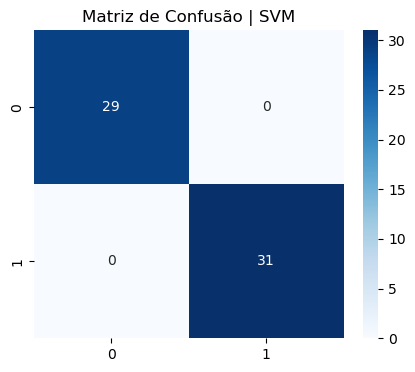

In [22]:
# Métricas de Avaliação

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Desempenho do Modelo de SVM")
print(f"\nAcurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Plot da Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Matriz de Confusão | SVM");

### Etapa 7 - Árvore de Decisão

1. Treine uma Árvore de Decisão para classificar as duas classes.
2. Visualize a árvore e a fronteira de decisão no espaço.
3. Avalie métricas de desempenho: acurácia, precisão, recall, F1-score.

In [23]:
dt_model = DecisionTreeClassifier(random_state=random_state)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

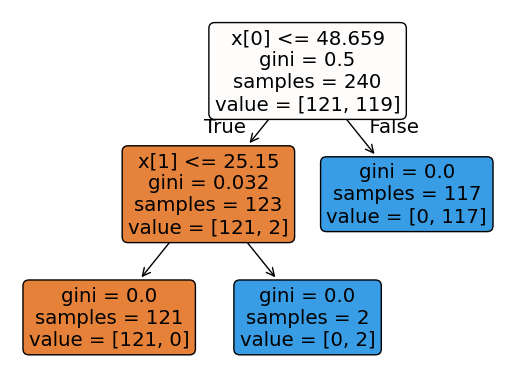

In [24]:
# Plot da Árvore de Decisão
# (o resultado é bem ilustrado no plot da fronteira de decisão apresentado abaixo)

plot_tree(dt_model, filled=True, rounded=True);

Text(0.5, 1.0, 'Fronteira de Decisão | Árvore de Decisão')

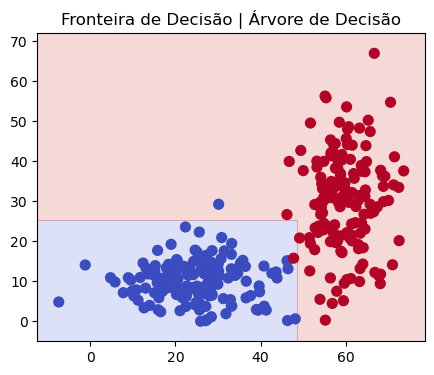

In [25]:
# Plot da Fronteira de Decisão

# x_min, x_max = data[:, 0].min() - 5, data[:, 0].max() + 5
# y_min, y_max = data[:, 1].min() - 5, data[:, 1].max() + 5

# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

Z_dt = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_dt = Z_dt.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z_dt, alpha=0.2, cmap="coolwarm")
plt.scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
plt.title("Fronteira de Decisão | Árvore de Decisão")

Desempenho do Modelo de Árvore de Decisão

Acurácia: 0.9667
Precisão: 0.9677
Recall: 0.9677
F1-score: 0.9677


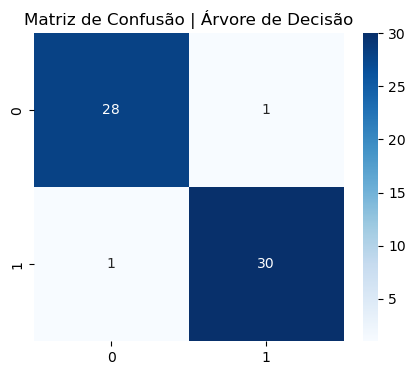

In [26]:
# Métricas de Avaliação

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Desempenho do Modelo de Árvore de Decisão")
print(f"\nAcurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Plot da Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Matriz de Confusão | Árvore de Decisão");

### Etapa 8 - K-Vizinhos Mais Próximos (KNN)

1. Treine um modelo KNN usando os dados de treino.
2. Plote a fronteira de decisão para cada $k$.
3. Compare métricas de desempenho (acurácia, precisão, recall, F1-score) com os outros
modelos.


In [27]:
models = {}
k_values = [1, 5, 10, 20, 50] # Foram Pré-Definidos 5 Valores de K (Número de Vizinhos) para Comparação

# Treina os modelos KNN
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    models[f"KNN (k={k})"] = knn

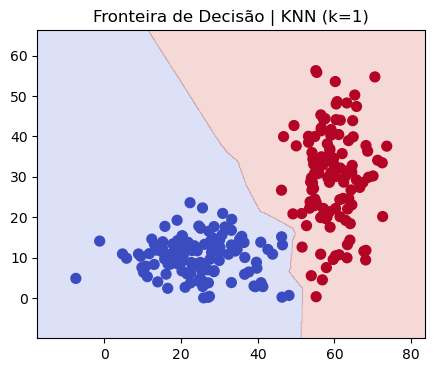

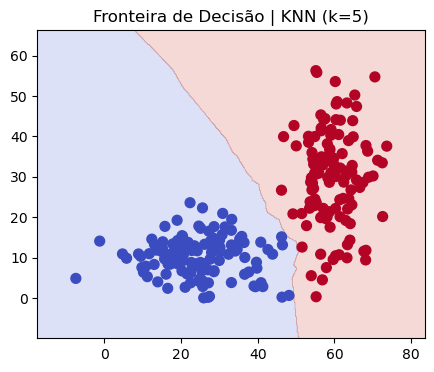

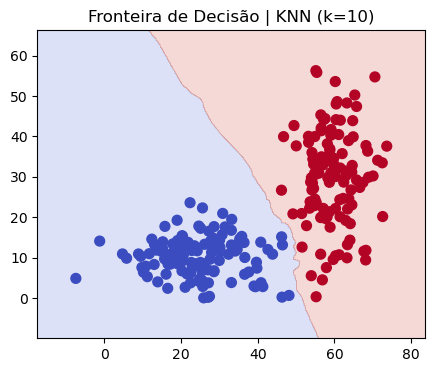

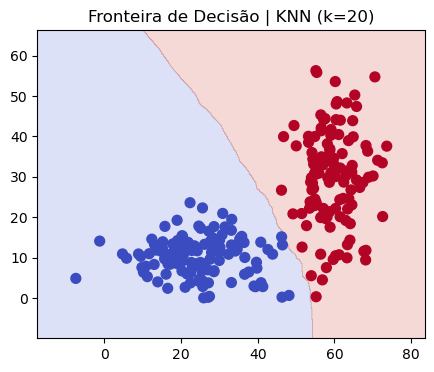

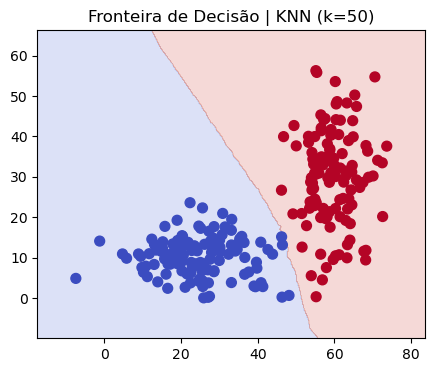

In [28]:
# Plot da Fronteira de Decisão


def plot_decision_boundary(X, y, model, title):
    """
    Função para plotar a fronteira de decisão de um modelo de classificação.
    """
    h = 0.2  # Tamanho do passo na grade (mesh)

    # Cria a grade de pontos
    x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
    y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Faz a predição em cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plota o gráfico
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.2)

    # Plota os pontos de dados (treino)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=50)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)


for name, model in models.items():
    plot_decision_boundary(X_train, y_train, model, f"Fronteira de Decisão | {name}")


Relatório para: KNN (k=1)
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        31

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Relatório para: KNN (k=5)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        31

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


Relatório para: KNN (k=10)
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        31

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98   

,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
KNN (k=1),0.983333,0.983889,0.983333,0.983338
KNN (k=5),1.000000,1.000000,1.000000,1.000000
KNN (k=10),0.983333,0.983889,0.983333,0.983338
KNN (k=20),1.000000,1.000000,1.000000,1.000000
KNN (k=50),1.000000,1.000000,1.000000,1.000000


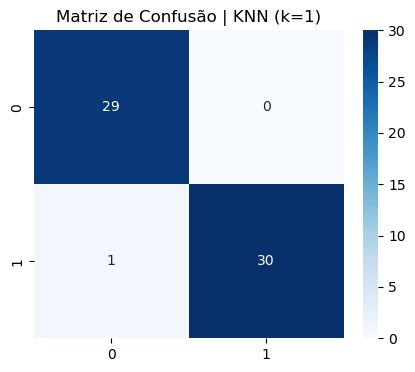

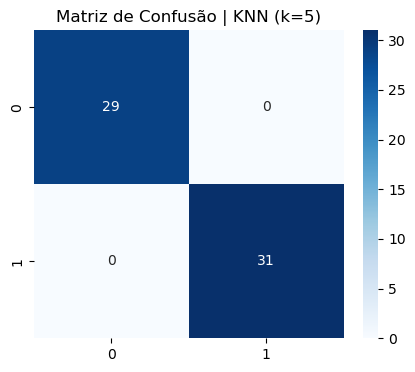

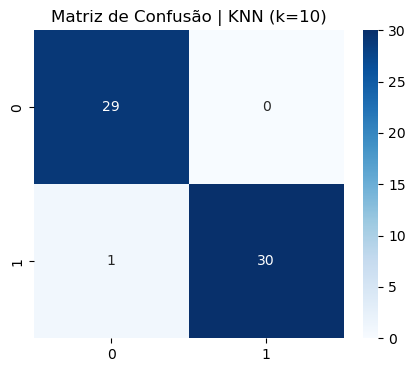

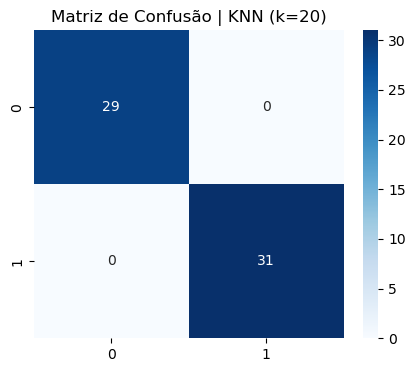

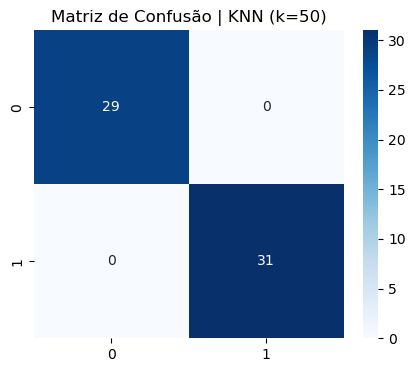

In [29]:
# Métricas de Avaliação

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Gera o relatório de classificação (opcional, mas bom para ver)
    print(f"\nRelatório para: {name}")
    print(classification_report(y_test, y_pred))

    # Plot da Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
    plt.title(f"Matriz de Confusão | {name}");

    # Coleta as métricas para o DataFrame
    results.append(
        {
            "Modelo": name,
            "Acurácia": accuracy_score(y_test, y_pred),
            "Precisão": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1-Score": f1_score(y_test, y_pred, average="weighted"),
        }
    )

# Cria e exibe o DataFrame de resultados
df_results = pd.DataFrame(results).set_index("Modelo")
display(df_results)